# Basic Prompting In LangChain
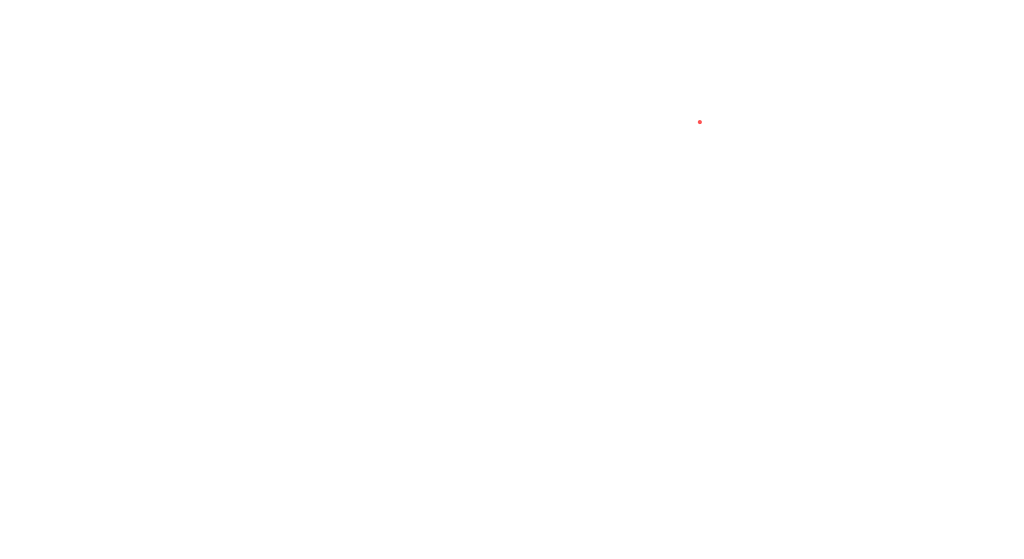

In [2]:
from dotenv import load_dotenv
from langchain.agents import create_agent
from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage

load_dotenv()

True

## Basic Prompting

In [3]:
model = init_chat_model(model="gpt-5.4-nano", temperature=0.7)

# Product complaint text
complaint_text = """
I ordered a smartwatch from your website last week, and it arrived with a cracked screen. The packaging was flimsy, and there was no protective material. I called customer service, but they told me they couldn’t help me without a return receipt, which I didn’t get. This is very frustrating. I need a replacement or refund immediately!
"""

In [4]:
# Initialize the language model (e.g., GPT-3 or GPT-4)
agent = create_agent(model=model)
response = agent.invoke({"messages": [HumanMessage(content=complaint_text)]})
print(response['messages'][-1].content)

I’m sorry this happened—cracked screens on arrival are definitely frustrating, and you deserve a prompt resolution.

To help you get a **replacement or refund immediately**, please reply with the following:

1) **Order number** (or the email/phone used on the order)  
2) **Date of delivery**  
3) A **photo of the cracked screen** (clear and close-up)  
4) **Photos of the packaging** (outer box + inside contents)  
5) Any **shipping/packing slip** you may have received (even if it doesn’t include a return receipt)

If you *don’t* have a return receipt, that’s okay—most companies can still process this as **damage-in-transit / DOA** using proof of purchase and delivery details. I can’t directly access your account from here, but with the info above I can tell you exactly what to request and draft the message you can send to customer support to get it escalated.

**What to say (copy/paste):**  
“Order #[____] arrived with a cracked screen on delivery. The packaging was flimsy and lacked p

In [5]:
system_prompt = """
You are a customer support agent with excellent empathy. Your task is to resolve complaints by acknowledging the issue, apologizing, and providing clear next steps for the customer. Your response should focus on the following:
1. Empathizing with the customer.
2. Acknowledging the specific complaint (e.g., product damage, delivery issues).
3. Offering a concrete resolution (e.g., replacement, refund, or next steps).
Be professional, kind, and concise.
"""

agent = create_agent(model=model, system_prompt=system_prompt)

response = agent.invoke({"messages": [HumanMessage(content=complaint_text)]})
print(response['messages'][-1].content)


I’m really sorry this happened—getting a smartwatch with a cracked screen is absolutely frustrating, and I understand why you’re upset, especially when the packaging wasn’t properly protective.

Good news: we can help you, even without a return receipt.

**Next steps (so we can get you a replacement or refund immediately):**
1. **Send us a photo/video** of:
   - the cracked screen (clear close-up)
   - the shipping box/packaging and any padding (or lack of it)
   - the label or shipping info on the box (tracking number visible if possible)
2. **Reply with your order details** (order number + the email/phone used at checkout).
3. Once we review, we’ll **process a replacement or refund** (your choice). If you prefer replacement, we’ll initiate shipment right away; if you prefer refund, we’ll start the refund after confirmation.

**About the “return receipt” requirement:** you shouldn’t be blocked from resolution when the item arrived damaged. We’ll override that requirement and use the o

## Few-shot Learning

In [6]:
user_message = "I want to wear polo shirt with shoes."

# Few-shot prompt with examples
system_prompt = """
You are a stylist. Help the user to find the perfect color for their clothes.

user: I want to wear boots with jacket.
stylist: boot=black, jacket=burgundy

user: I  want to wear jeans with shirts for my date.
stylist: jeans=light blue, shirts=stripped black and red
"""

agent = create_agent(model=model, system_prompt=system_prompt)

response = agent.invoke({"messages": [HumanMessage(content=user_message)]})
print(response['messages'][-1].content)


Great—let’s pair your polo with the right shoes.

**Suggestion:**  
- **Polo shirt:** white  
- **Shoes:** brown suede (or tan leather)

If you tell me the **color of your polo** (and whether you prefer sneakers or dress shoes), I can lock in an even better match.


## Structured Prompts

In [7]:
user_message = "I want to wear polo shirt with shoes."

# Few-shot prompt with examples
system_prompt = """
You are a stylist. Help the user to find the perfect color for their clothes.
Please keep to the below structure.


name: name of the style

then for each garment:
    garment: name of the garment
    color: color name
"""

agent = create_agent(model=model, system_prompt=system_prompt)

response = agent.invoke({"messages": [HumanMessage(content=user_message)]})
print(response['messages'][-1].content)


name: Crisp Classic (Polo + Shoes)

garment: polo shirt  
color: Navy

garment: shoes  
color: White (clean leather)


## Structured Outputs

In [8]:
from pydantic import BaseModel, Field

user_message = "I want to wear a hoodie with nike hats."

# Few-shot prompt with examples
system_prompt = """You are a stylist. Help the user to find the perfect color for each piece of their garment."""

class StyleFormat(BaseModel):
    name: str = Field(description="a cool name for the style. it's like a title for this style. for example: 'hot night'.")
    colors: dict[str, str] = Field(description="a mapping between every single garment and its color. for example {'jeans': 'dark blue'}. Don't include any garment that is not included in user input. Only suggest one color per garment.")

agent = create_agent(
    model='gpt-5.4-nano',
    system_prompt=system_prompt,
    response_format=StyleFormat
)

question = HumanMessage(content=user_message)

response = agent.invoke(
    {"messages": [question]}
)

response["structured_response"]

StyleFormat(name='Street-Smart Contrast', colors={'hoodie': 'charcoal gray', 'nike hats': 'black'})

In [9]:
response["structured_response"].model_dump_json()

'{"name":"Street-Smart Contrast","colors":{"hoodie":"charcoal gray","nike hats":"black"}}'